In [6]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [11]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")
includet("./reports.jl")

In [8]:
using JLD2
using DataFrames, DataFramesMeta

In [9]:
includet("../../../scripts/figures_util.jl")

In [10]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

In [38]:
do_everything_ps("./wrtp_k0.5_wide/", [1.0, 0.1, 0.01];
    fs_K_step=2,
);

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict

In [20]:
do_everything_ps("./wrtp_k0_zoom/", [1.0, 0.1, 0.01];
    fs_K_step=4,
);

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict

# Get data from all files

In [21]:
for f in files
    close(f)
end
GC.gc()

LoadError: UndefVarError: `files` not defined

In [22]:
ps = [1.0, 0.1, 0.01]
files = map(ps) do p
    jldopen("./wrtp_k0_zoom//p$p.jld2")
end;
Ks = files[1]["metadata"].Ks;

In [26]:
full_df = DataFrame(;
    K=Float64[],
    p=Float64[],
    retcode=Any[],
    fT=Any[],
    fs=Any[],
)
for (p, f) in zip(ps, files)
    fKs = f["Ks"]
    results = f["results"]
    for i in 1:length(fKs)
        r = results[i]
        for (rc, fT, fs) in zip(r.retcodes, r.fTs, r.fss)
            push!(full_df, (fKs[i], p, rc, fT, fs))
        end
    end
end
df = @subset(full_df, :fT .== 1e8, :retcode .== ReturnCode.Success);
nrow(df)

4468

In [10]:
jldsave("./wrtp_2/df.jld2"; df=full_df, metadata=files[1]["metadata"])

## Number of survivors

In [27]:
df.num_surv = num_survivors_in_space.(df.fs, 2);

In [28]:
pgroups = @groupby(df, :p);

# Plotting final states

In [28]:
for i in 1:length(files)
    fig = plot_many_final_states(files[i], 10, 1:2:length(Ks))
    Label(fig[0,:], (@sprintf "This is for p=%.3g." ps[i]); fontsize=30)
    Makie.save("./wrtp_2/fs_$i.pdf", fig)
end

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict

# Plotting outcomes

In [37]:
for i in 1:length(files)
    f = files[i]
    fmetadata = f["metadata"]
    Ks = f["Ks"]
    numKs = length(Ks)
    results = f["results"];
    
    surv_threshold = 1e-9
    num_ext = zeros(numKs)
    num_coex = zeros(numKs)
    num_S1 = zeros(numKs)
    num_S2 = zeros(numKs)
    num_bad = zeros(numKs)
    for iK in 1:length(Ks)
        for (rc, fT, fs) in zip(results[iK].retcodes, results[iK].fTs, results[iK].fss)
            if (fT == fmetadata.T) && (rc == ReturnCode.Success)
                m1 = mean(@view fs[1,:])
                m2 = mean(@view fs[2,:])
                if (m1 < surv_threshold) && (m2 < surv_threshold)
                    num_ext[iK] += 1
                elseif (m1 < surv_threshold)
                    num_S2[iK] += 1
                elseif (m2 < surv_threshold)
                    num_S1[iK] += 1
                else
                    num_coex[iK] += 1
                end
            else
                num_bad[iK] += 1
            end
        end
    end
    @assert all((num_ext .+ num_coex .+ num_S1 .+ num_S2 .+ num_bad) .== fmetadata.numrepeats)
    
    fig = Figure(;)
    ax = Axis(fig[1,1];
        # xscale=log10,
        xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
        ylabel=L"\text{Counts}",
    )

    plot_binom_sample!(ax, Ks, num_ext, fmetadata.numrepeats;
        color=PaperColors.extinct1(),
        label="Extinction",
        sl_kwargs=(; markersize=0.),
    )
    plot_binom_sample!(ax, Ks, num_S1, fmetadata.numrepeats;
        color=PaperColors.twomms_1(),
        label="Only 1",
        sl_kwargs=(; markersize=0.),
    )
    plot_binom_sample!(ax, Ks, num_S2, fmetadata.numrepeats;
        color=PaperColors.twomms_2(),
        label="Only 2",
        sl_kwargs=(; markersize=0.),
    )
    plot_binom_sample!(ax, Ks, num_coex, fmetadata.numrepeats;
        color=PaperColors.twomms_coexistence(),
        label="Coexistence",
        sl_kwargs=(; markersize=0.),
    )
    plot_binom_sample!(ax, Ks, num_bad, fmetadata.numrepeats;
        color=:orange,
        label="Bad",
    )
    
    Label(fig[0,:], (@sprintf "This is for p=%.3g." ps[i]);
        fontsize=20,
        tellwidth=false,
    )
    Makie.save("./wrtp_k0_zoom/outcomes_$i.pdf", fig)
end

# Box plots of num survivors

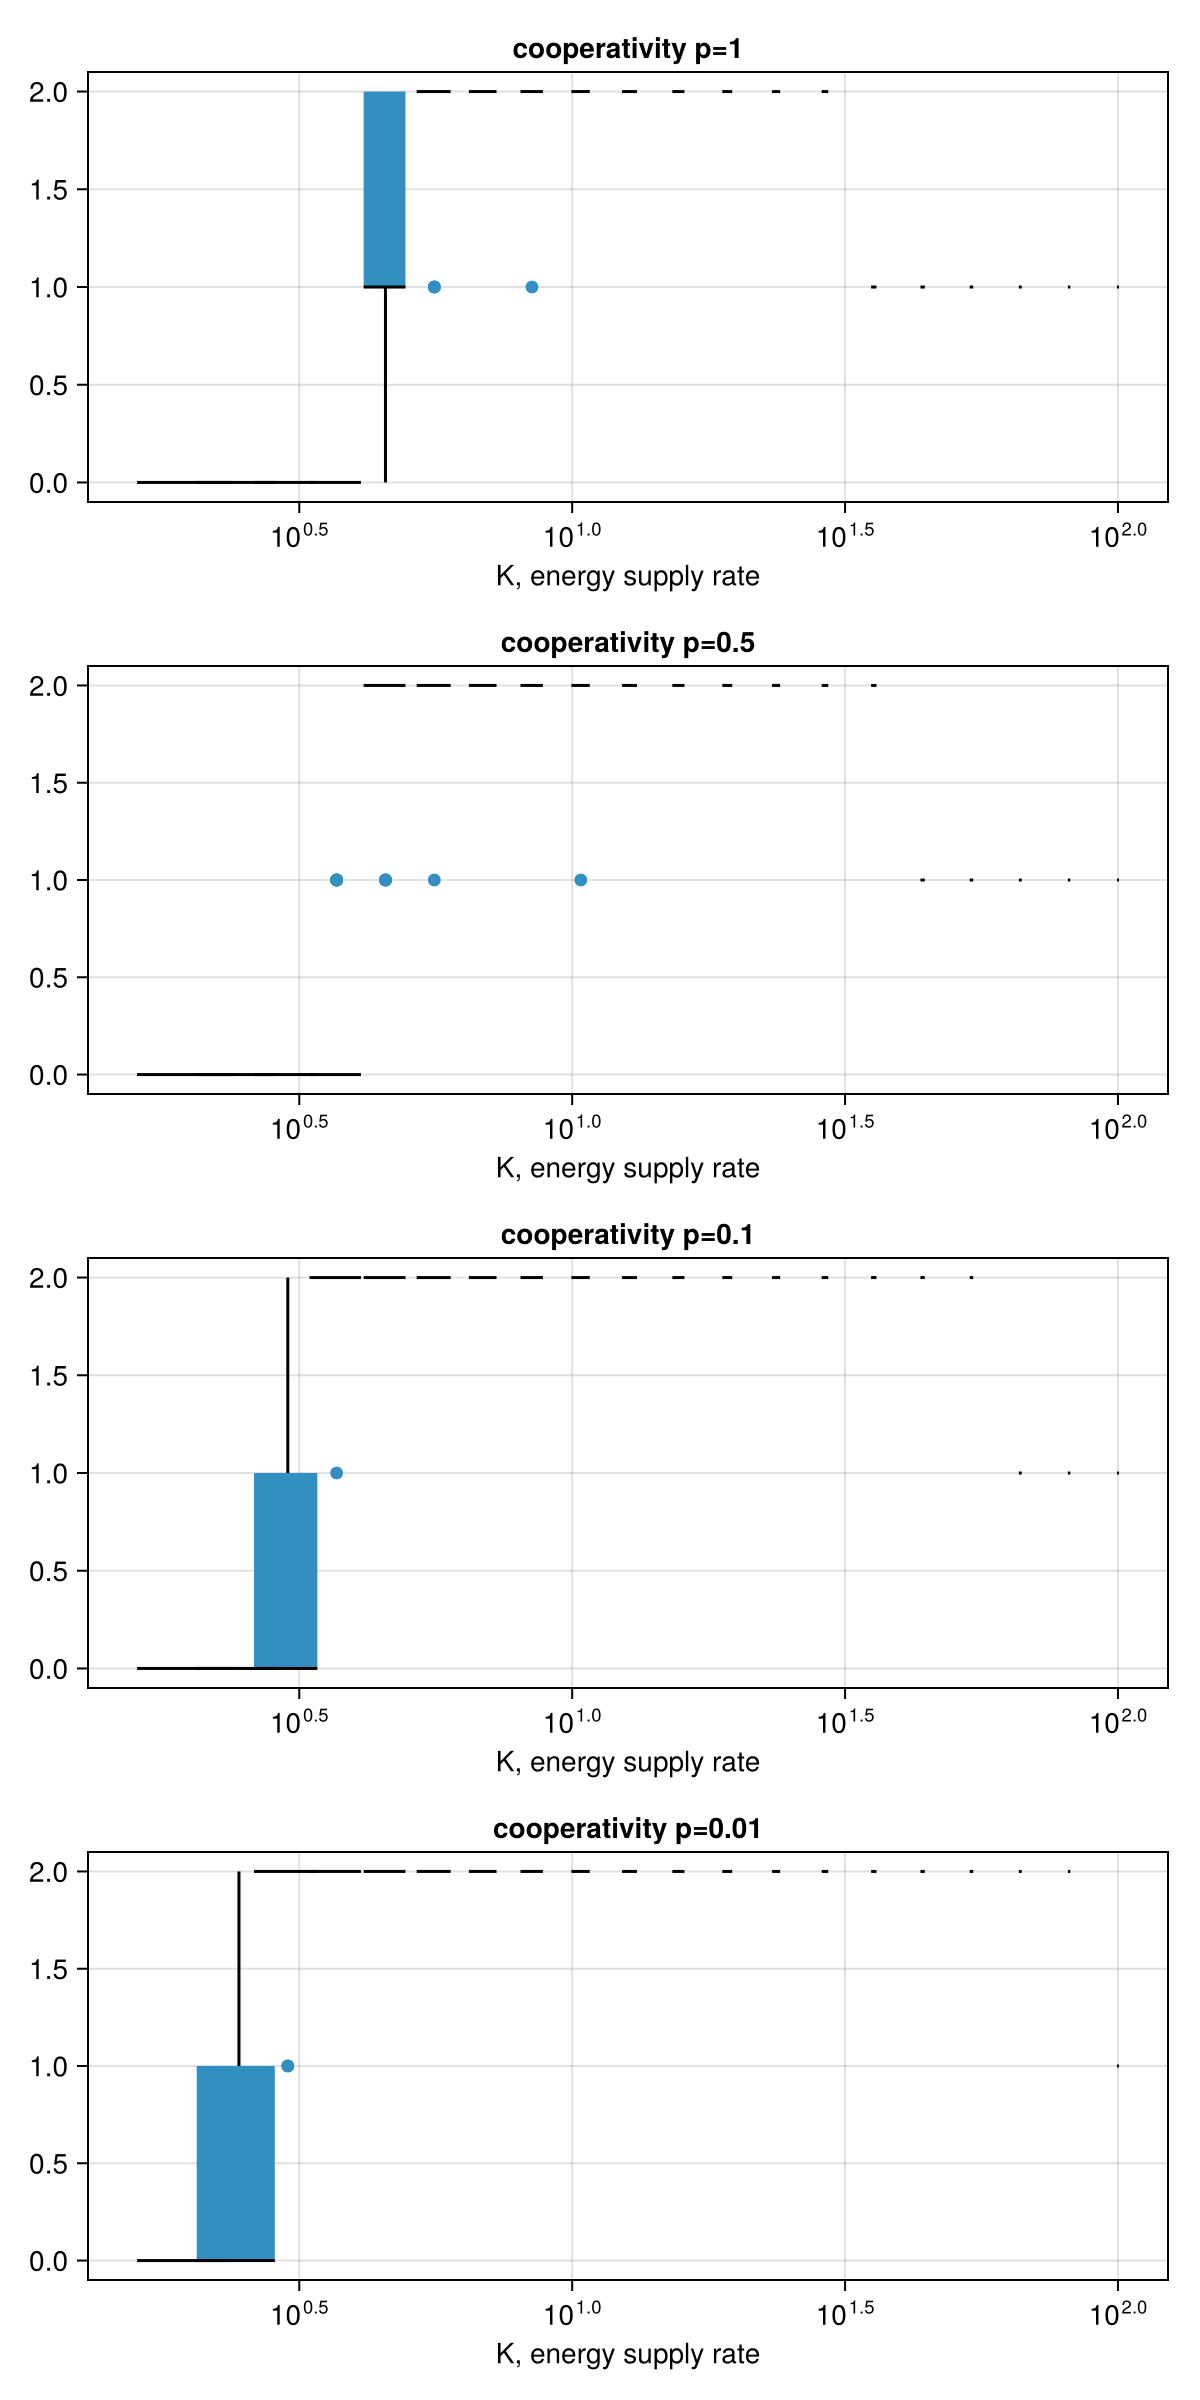

In [13]:
fig = Figure(;
    size=(600, 300 * length(pgroups))
)
for (i, sdf) in enumerate(pgroups)
    ax = Axis(fig[i,1];
        xscale=log10,
        title=(@sprintf "cooperativity p=%.3g" sdf.p[1]),
        xlabel="K, energy supply rate",
    )
    boxplot!(ax, sdf.K, sdf.num_surv)
end
Makie.save("wrtp_2/num_surv_bp.pdf", fig)
fig